In [1]:
from pathlib import Path
from scipy import stats

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

INPUT_DATA_DIR = Path.cwd() / "data_notebook1" / "input_data"
OUTPUT_TABLES = Path.cwd() / "data_notebook1" / "output_data" / "tables"
OUTPUT_CHARTS = Path.cwd() / "data_notebook1" / "output_data" / "charts"

if not INPUT_DATA_DIR.exists():
    raise FileNotFoundError(
        f"Could not find data directory: {INPUT_DATA_DIR}"
    )

if not OUTPUT_TABLES.exists():
    raise FileNotFoundError(
        f"Could not find data directory: {OUTPUT_TABLES}"
    )
    
if not OUTPUT_CHARTS.exists():
    raise FileNotFoundError(
        f"Could not find data directory: {OUTPUT_CHARTS}"
    )

print("Input data directory detected:", INPUT_DATA_DIR)
print("Output tables data directory detected:", OUTPUT_TABLES)
print("Output charts data directory detected:", OUTPUT_CHARTS)
print("Notebook setup complete.")

Input data directory detected: /home/lucap/IE_University_Linux/Other/eden_application/notebooks/data_notebook1/input_data
Output tables data directory detected: /home/lucap/IE_University_Linux/Other/eden_application/notebooks/data_notebook1/output_data/tables
Output charts data directory detected: /home/lucap/IE_University_Linux/Other/eden_application/notebooks/data_notebook1/output_data/charts
Notebook setup complete.


In [2]:
# Define official raw candidate CSV files

candidate_files = {
    "Orion": INPUT_DATA_DIR / "orion_eod.csv",
    "Cleanergy": INPUT_DATA_DIR / "cleanergy_eod.csv",
    "NovaTerra": INPUT_DATA_DIR / "novaterra_eod.csv",
}

# Validate that all expected files exist
for candidate, file_path in candidate_files.items():
    if not file_path.exists():
        raise FileNotFoundError(f"Missing file for {candidate}: {file_path}")

    print(f"{candidate} file found: {file_path}")

Orion file found: /home/lucap/IE_University_Linux/Other/eden_application/notebooks/data_notebook1/input_data/orion_eod.csv
Cleanergy file found: /home/lucap/IE_University_Linux/Other/eden_application/notebooks/data_notebook1/input_data/cleanergy_eod.csv
NovaTerra file found: /home/lucap/IE_University_Linux/Other/eden_application/notebooks/data_notebook1/input_data/novaterra_eod.csv


In [3]:
# Load raw candidate price data and inspect structure

raw_data = {}

raw_data_summary = []

for candidate, file_path in candidate_files.items():
    df = pd.read_csv(file_path)
    raw_data[candidate] = df

    raw_data_summary.append({
        "Candidate": candidate,
        "File": file_path.name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Column Names": list(df.columns),
        "Total Missing Values": df.isna().sum().sum(),
    })

raw_data_summary_df = pd.DataFrame(raw_data_summary)

display(raw_data_summary_df)

,Candidate,File,Rows,Columns,Column Names,Total Missing Values
0,Orion,orion_eod.csv,1745,2,"[Date, Close]",0
1,Cleanergy,cleanergy_eod.csv,2189,2,"[Date, Close]",0
2,NovaTerra,novaterra_eod.csv,3519,2,"[Date, Close]",0


In [4]:
# Clean candidate price data for time-series analysis

price_data = {}
cleaning_summary = []

for candidate, df in raw_data.items():
    clean_df = df.copy()

    required_columns = {"Date", "Close"}
    missing_columns = required_columns - set(clean_df.columns)

    if missing_columns:
        raise ValueError(f"{candidate} is missing columns: {missing_columns}")

    clean_df["Date"] = pd.to_datetime(clean_df["Date"], errors="coerce")
    clean_df["Close"] = pd.to_numeric(clean_df["Close"], errors="coerce")

    clean_df = (
        clean_df
        .dropna(subset=["Date", "Close"])
        .sort_values("Date")
        .drop_duplicates(subset=["Date"], keep="last")
        .set_index("Date")
    )

    price_data[candidate] = clean_df

    cleaning_summary.append({
        "Candidate": candidate,
        "Start Date": clean_df.index.min().date(),
        "End Date": clean_df.index.max().date(),
        "Observations": len(clean_df),
    })

cleaning_summary_df = pd.DataFrame(cleaning_summary)

display(cleaning_summary_df)

,Candidate,Start Date,End Date,Observations
0,Orion,2019-06-20,2026-02-25,1745
1,Cleanergy,2018-01-02,2026-05-22,2189
2,NovaTerra,2012-08-31,2026-02-25,3519


In [5]:
# Calculate simple daily returns from cleaned closing prices

returns_data = {}
returns_summary = []

for candidate, df in price_data.items():
    returns = df["Close"].pct_change().dropna()
    returns_data[candidate] = returns

    returns_summary.append({
        "Candidate": candidate,
        "Return Observations": len(returns),
        "Mean Daily Return": returns.mean(),
        "Daily Volatility": returns.std(),
        "Min Daily Return": returns.min(),
        "Max Daily Return": returns.max(),
    })

returns_summary_df = pd.DataFrame(returns_summary)

display(
    returns_summary_df.style.format({
        "Mean Daily Return": "{:.4%}",
        "Daily Volatility": "{:.4%}",
        "Min Daily Return": "{:.2%}",
        "Max Daily Return": "{:.2%}",
    })
)

,Candidate,Return Observations,Mean Daily Return,Daily Volatility,Min Daily Return,Max Daily Return
0,Orion,1744,0.2382%,3.5641%,-28.49%,25.92%
1,Cleanergy,2188,0.0704%,2.8959%,-7.25%,7.38%
2,NovaTerra,3518,0.0212%,2.0034%,-7.07%,6.63%


In [6]:
# Combine candidate returns using the union of all available dates

returns_df_all_dates = pd.DataFrame(returns_data)

missing_returns_summary = (
    returns_df_all_dates
    .isna()
    .sum()
    .to_frame("Missing Return Observations")
)

print("Combined returns shape using all available dates:", returns_df_all_dates.shape)

display(missing_returns_summary)

Combined returns shape using all available dates: (3580, 3)


,Missing Return Observations
Orion,1836
Cleanergy,1392
NovaTerra,62


In [7]:
# Create common-date returns dataframe for fair candidate comparison

returns_df_common = returns_df_all_dates.dropna()

print("Common-date returns shape:", returns_df_common.shape)
print("\nMissing values after common-date alignment:")
print(returns_df_common.isna().sum())

print("\nCommon period:")
print(f"Start date: {returns_df_common.index.min().date()}")
print(f"End date: {returns_df_common.index.max().date()}")

Common-date returns shape: (1744, 3)

Missing values after common-date alignment:
Orion        0
Cleanergy    0
NovaTerra    0
dtype: int64

Common period:
Start date: 2019-06-21
End date: 2026-02-25


In [8]:
# Define analysis assumptions

TRADING_DAYS = 252
RISK_FREE_RATE = 0.03
POSITION_SIZE = 5000


def calculate_metrics(candidate, prices, returns):
    """
    Calculate standalone risk/return metrics for one candidate.
    Uses simple daily returns and each candidate's full available price history.
    """

    prices = prices.dropna()
    returns = returns.dropna()

    start_price = prices.iloc[0]
    end_price = prices.iloc[-1]
    n_days = len(returns)

    cumulative_return = end_price / start_price - 1
    annualized_return = (end_price / start_price) ** (TRADING_DAYS / n_days) - 1
    annualized_volatility = returns.std() * np.sqrt(TRADING_DAYS)

    sharpe_ratio = np.nan
    if annualized_volatility != 0:
        sharpe_ratio = (annualized_return - RISK_FREE_RATE) / annualized_volatility

    cumulative_growth = (1 + returns).cumprod()
    drawdown = cumulative_growth / cumulative_growth.cummax() - 1
    max_drawdown = drawdown.min()

    var_threshold = np.percentile(returns, 5)
    var_95 = -var_threshold
    cvar_95 = -returns[returns <= var_threshold].mean()

    skewness = stats.skew(returns)
    excess_kurtosis = stats.kurtosis(returns)

    return {
        "Candidate": candidate,
        "Start Date": prices.index.min().date(),
        "End Date": prices.index.max().date(),
        "Observations": n_days,
        "Cumulative Return": cumulative_return,
        "Ann. Return": annualized_return,
        "Ann. Volatility": annualized_volatility,
        "Sharpe Ratio": sharpe_ratio,
        "Max Drawdown": max_drawdown,
        "VaR 95%": var_95,
        "VaR 95% €": var_95 * POSITION_SIZE,
        "CVaR 95%": cvar_95,
        "CVaR 95% €": cvar_95 * POSITION_SIZE,
        "Skewness": skewness,
        "Excess Kurtosis": excess_kurtosis,
    }


metrics = []

for candidate in price_data:
    prices = price_data[candidate]["Close"]
    returns = returns_data[candidate]
    metrics.append(calculate_metrics(candidate, prices, returns))

metrics_df = pd.DataFrame(metrics)

display(
    metrics_df.style.format({
        "Cumulative Return": "{:.2%}",
        "Ann. Return": "{:.2%}",
        "Ann. Volatility": "{:.2%}",
        "Sharpe Ratio": "{:.2f}",
        "Max Drawdown": "{:.2%}",
        "VaR 95%": "{:.2%}",
        "VaR 95% €": "€{:.2f}",
        "CVaR 95%": "{:.2%}",
        "CVaR 95% €": "€{:.2f}",
        "Skewness": "{:.2f}",
        "Excess Kurtosis": "{:.2f}",
    })
)

,Candidate,Start Date,End Date,Observations,Cumulative Return,Ann. Return,Ann. Volatility,Sharpe Ratio,Max Drawdown,VaR 95%,VaR 95% €,CVaR 95%,CVaR 95% €,Skewness,Excess Kurtosis
0,Orion,2019-06-20,2026-02-25,1744,1975.96%,55.00%,56.58%,0.92,-62.76%,5.78%,€288.83,8.23%,€411.63,-0.34,5.57
1,Cleanergy,2018-01-02,2026-05-22,2188,86.28%,7.43%,45.97%,0.10,-93.04%,4.83%,€241.74,5.58%,€279.24,-0.00,-0.59
2,NovaTerra,2012-08-31,2026-02-25,3518,4.13%,0.29%,31.80%,-0.09,-87.48%,3.29%,€164.64,4.12%,€205.96,0.02,0.03


In [9]:
# Export numeric metrics for downstream analysis

raw_metrics_path = OUTPUT_TABLES / "candidate_metrics_raw.csv"

metrics_df.to_csv(raw_metrics_path, index=False)

print("Exported numeric candidate metrics to:")
print(raw_metrics_path)

Exported numeric candidate metrics to:
/home/lucap/IE_University_Linux/Other/eden_application/notebooks/data_notebook1/output_data/tables/candidate_metrics_raw.csv


In [10]:
# Compute candidate return correlations using common trading dates

print("Common-date observations:", len(returns_df_common))

correlation_matrix = returns_df_common.corr()

display(correlation_matrix.round(3))

correlation_path = OUTPUT_TABLES / "candidate_return_correlations.csv"
correlation_matrix.to_csv(correlation_path)

print("Exported correlation matrix to:")
print(correlation_path)

Common-date observations: 1744


,Orion,Cleanergy,NovaTerra
Orion,1.000,-0.020,0.067
Cleanergy,-0.020,1.000,0.005
NovaTerra,0.067,0.005,1.000


Exported correlation matrix to:
/home/lucap/IE_University_Linux/Other/eden_application/notebooks/data_notebook1/output_data/tables/candidate_return_correlations.csv


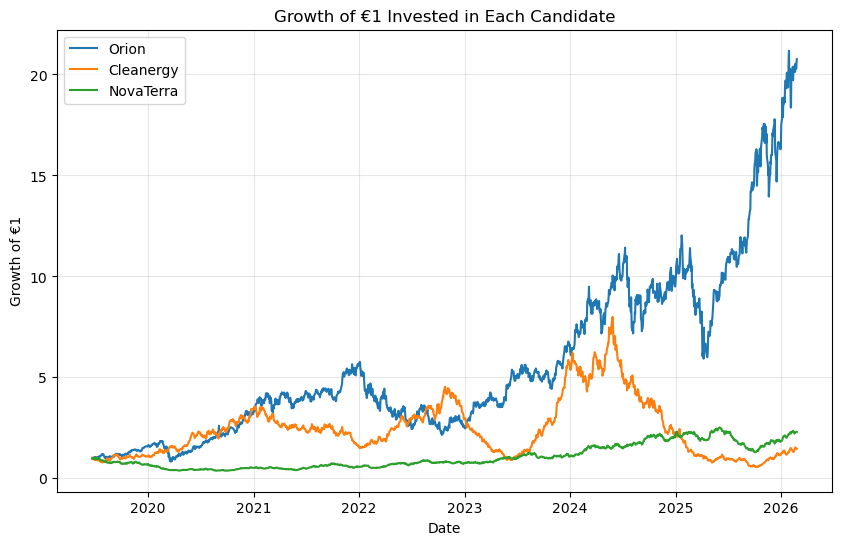

Exported chart to:
/home/lucap/IE_University_Linux/Other/eden_application/notebooks/data_notebook1/output_data/charts/candidate_growth_of_1.png


In [11]:
# Plot growth of €1 invested in each candidate using common dates

growth_of_1_df = (1 + returns_df_common).cumprod()

plt.figure(figsize=(10, 6))

for candidate in growth_of_1_df.columns:
    plt.plot(growth_of_1_df.index, growth_of_1_df[candidate], label=candidate)

plt.title("Growth of €1 Invested in Each Candidate")
plt.xlabel("Date")
plt.ylabel("Growth of €1")
plt.legend()
plt.grid(True, alpha=0.3)

chart_path = OUTPUT_CHARTS / "candidate_growth_of_1.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Exported chart to:")
print(chart_path)

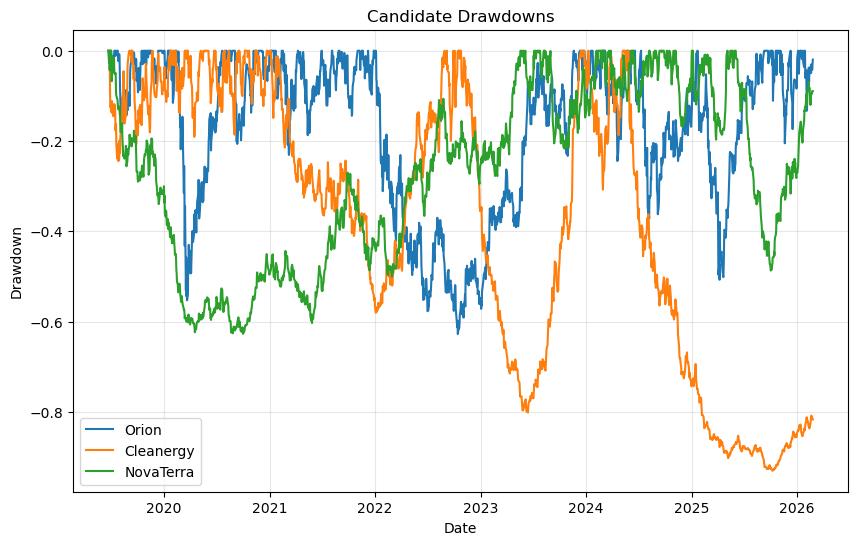

Exported chart to:
/home/lucap/IE_University_Linux/Other/eden_application/notebooks/data_notebook1/output_data/charts/candidate_drawdowns.png


In [12]:
# Plot candidate drawdowns over time using common dates

cumulative_growth_common = (1 + returns_df_common).cumprod()
drawdowns_df = cumulative_growth_common / cumulative_growth_common.cummax() - 1

plt.figure(figsize=(10, 6))

for candidate in drawdowns_df.columns:
    plt.plot(drawdowns_df.index, drawdowns_df[candidate], label=candidate)

plt.title("Candidate Drawdowns")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True, alpha=0.3)

chart_path = OUTPUT_CHARTS / "candidate_drawdowns.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Exported chart to:")
print(chart_path)

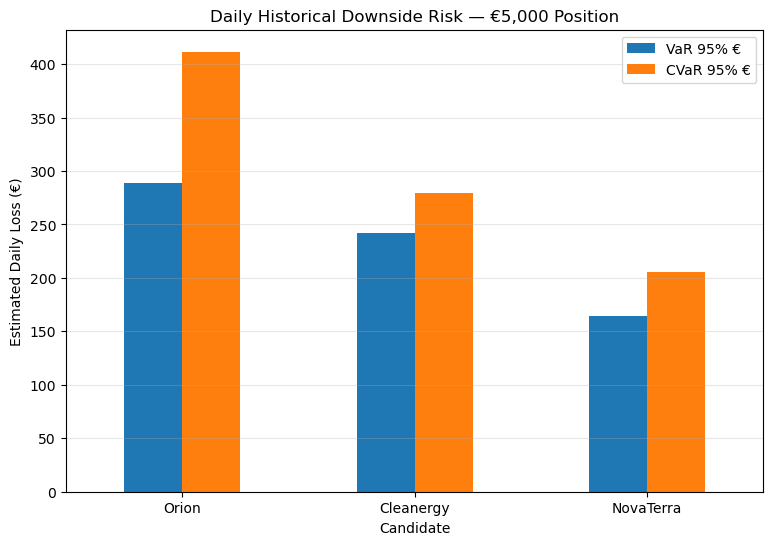

Exported chart to:
/home/lucap/IE_University_Linux/Other/eden_application/notebooks/data_notebook1/output_data/charts/candidate_var_cvar_eur.png


In [13]:
# Plot daily historical VaR and CVaR for a €5,000 position

var_cvar_chart_data = metrics_df.set_index("Candidate")[["VaR 95% €", "CVaR 95% €"]]

ax = var_cvar_chart_data.plot(kind="bar", figsize=(9, 6))

plt.title("Daily Historical Downside Risk — €5,000 Position")
plt.xlabel("Candidate")
plt.ylabel("Estimated Daily Loss (€)")
plt.xticks(rotation=0)
plt.grid(True, axis="y", alpha=0.3)

chart_path = OUTPUT_CHARTS / "candidate_var_cvar_eur.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Exported chart to:")
print(chart_path)

## Public ETF and Stock Alternative Benchmarking

This section extends the standalone candidate analysis by comparing Orion, Cleanergy, and NovaTerra with a compact set of public ETF and stock alternatives. The purpose is to test whether a fictional candidate offers better risk-adjusted exposure than a diversified public ETF or a real public company with similar economic exposure.

The main benchmark pairs are Orion vs SMH, Cleanergy vs GRID, and NovaTerra vs MOO. Selected public stocks are included only where they represent realistic investable alternatives, not simply because they are peers.

The key question is whether each fictional candidate offers enough incremental return or differentiated exposure to justify single-name risk. These results will feed into Notebook 03 for portfolio-impact testing and Notebook 04 for the final recommendation.

In [14]:
# ============================================================
# Public ETF and Eligible Stock Alternative Universe
# ============================================================
#
# Objective:
# Define a compact public benchmark universe to test whether
# the fictional candidates offer better risk-adjusted exposure
# than realistic public alternatives.
#
# ETFs are used as primary thematic benchmarks.
#
# Stocks are included as possible public single-name alternatives
# only if they are expected to satisfy the following rules:
# - Publicly listed equity
# - OECD-listed market
# - Profitable company
# - Market cap between $3bn and $15bn
# - Not a derivative, leveraged product, warrant, option, or swap
#
# Final eligibility is verified in the market-cap screen below.
# ============================================================

etf_benchmarks = {
    "SMH": "Orion benchmark: semiconductors / AI chips",
    "GRID": "Cleanergy benchmark: smart-grid infrastructure",
    "MOO": "NovaTerra benchmark: agribusiness",
}

stock_alternatives = {
    "CRUS": "Orion alternative: profitable mid-cap fabless semiconductor company; less pure edge-AI exposure but cleaner public data and compliance profile",
    "ITRI": "Cleanergy alternative: smart-grid / utility infrastructure",
    "TRMB": "NovaTerra alternative: positioning, software, connected workflows, precision agriculture",
    "AGCO": "NovaTerra alternative: agricultural equipment and precision farming exposure",
}

qualitative_only_comps = {
    "LSCC": "Relevant low-power semiconductor peer, but excluded because it fails the market-cap constraint",
    "ALGM": "Relevant automotive/industrial semiconductor peer, but excluded because of missing price data and profitability caveat",

    "SOXX": "Secondary Orion ETF benchmark; excluded to avoid duplicating SMH",
    "ICLN": "Secondary Cleanergy ETF benchmark; broader and less precise than GRID",
    "XLU": "Existing EDEN holding; portfolio-overlap test belongs in Notebook 03",
    "VEGI": "Secondary NovaTerra ETF benchmark; excluded to avoid duplicating MOO",

    "QCOM": "Relevant Orion peer, but excluded as an eligible alternative due to market-cap constraint",
    "TSLA": "Relevant battery-storage peer, but excluded due to market-cap constraint and imperfect business-model fit",
    "ETN": "Relevant electrification peer, but excluded due to market-cap constraint",
    "DE": "Relevant precision-agriculture peer, but excluded due to market-cap constraint",

    "NVDA": "AI-chip leader but excluded due to market-cap constraint and ASML/AI concentration",
    "MRVL": "Relevant semiconductor comp but likely outside market-cap constraint",
    "ARM": "Relevant IP/licensing comp but likely outside market-cap constraint and shorter listed history",

    "ENPH": "Clean-energy electronics comp but less grid-scale than Cleanergy",
    "FLNC": "Closest Cleanergy pure-play, but likely profitability/compliance concern",
    "STEM": "Energy-storage software comp, but weak/risky profile and likely profitability concern",
    "EOSE": "Battery-storage comp, but major profitability/margin concern",
    "PL": "Closest NovaTerra satellite-data comp, but likely profitability concern",
}

public_tickers = list(etf_benchmarks.keys()) + list(stock_alternatives.keys())

benchmark_universe_df = pd.DataFrame(
    [
        {"Ticker": ticker, "Type": "ETF Benchmark", "Role": description}
        for ticker, description in etf_benchmarks.items()
    ]
    +
    [
        {"Ticker": ticker, "Type": "Eligible Stock Alternative Candidate", "Role": description}
        for ticker, description in stock_alternatives.items()
    ]
)

display(benchmark_universe_df)

print("Tickers downloaded for main quantitative comparison:")
print(public_tickers)


,Ticker,Type,Role
0,SMH,ETF Benchmark,Orion benchmark: semiconductors / AI chips
1,GRID,ETF Benchmark,Cleanergy benchmark: smart-grid infrastructure
2,MOO,ETF Benchmark,NovaTerra benchmark: agribusiness
3,CRUS,Eligible Stock Alternative Candidate,Orion alternative: profitable mid-cap fabless ...
4,ITRI,Eligible Stock Alternative Candidate,Cleanergy alternative: smart-grid / utility in...
5,TRMB,Eligible Stock Alternative Candidate,"NovaTerra alternative: positioning, software, ..."
6,AGCO,Eligible Stock Alternative Candidate,NovaTerra alternative: agricultural equipment ...


Tickers downloaded for main quantitative comparison:
['SMH', 'GRID', 'MOO', 'CRUS', 'ITRI', 'TRMB', 'AGCO']


In [15]:
# ============================================================
# Download Public ETF and Stock Alternative Prices
# ============================================================
#
# Data source:
# Yahoo Finance via yfinance.
#
# Methodology:
# - Use adjusted prices through auto_adjust=True.
# - Match the public alternative time window to the fictional
#   candidate common return window.
# - Drop tickers only if Yahoo Finance returns no usable data.
# ============================================================

import yfinance as yf

# Use the same date range as the common fictional candidate analysis
public_start_date = returns_df_common.index.min().strftime("%Y-%m-%d")
public_end_date = returns_df_common.index.max().strftime("%Y-%m-%d")

print("Downloading public alternative data from:")
print("Start date:", public_start_date)
print("End date:", public_end_date)

public_prices_raw = yf.download(
    public_tickers,
    start=public_start_date,
    end=public_end_date,
    auto_adjust=True,
    progress=False
)

# Extract close prices from yfinance output
if isinstance(public_prices_raw.columns, pd.MultiIndex):
    if "Close" in public_prices_raw.columns.get_level_values(0):
        public_prices = public_prices_raw["Close"].copy()
    else:
        raise ValueError("Could not find 'Close' prices in yfinance output.")
else:
    public_prices = public_prices_raw.copy()

# Remove tickers with no available data
public_prices = public_prices.dropna(axis=1, how="all")

print("\nDownloaded public price data")
print("Shape:", public_prices.shape)
print("Available tickers:", list(public_prices.columns))
print("Date range:", public_prices.index.min(), "to", public_prices.index.max())

Start date: 2019-06-21
End date: 2026-02-25

Downloaded public price data
Shape: (1678, 7)
Available tickers: ['AGCO', 'CRUS', 'GRID', 'ITRI', 'MOO', 'SMH', 'TRMB']
Date range: 2019-06-21 00:00:00 to 2026-02-24 00:00:00


In [16]:
# ============================================================
# Validate and Clean Downloaded Public Data
# ============================================================
#
# Check which requested tickers were successfully downloaded and
# exclude any ticker with excessive missing data over the common
# comparison window.
# ============================================================

requested_tickers = set(public_tickers)
downloaded_tickers = set(public_prices.columns)

missing_tickers = sorted(requested_tickers - downloaded_tickers)

missing_data_summary = (
    public_prices
    .isna()
    .mean()
    .sort_values(ascending=False)
    .to_frame("Missing Data %")
)

print("Missing tickers:", missing_tickers if missing_tickers else "None")

display(
    missing_data_summary.style.format({
        "Missing Data %": "{:.2%}"
    })
)

# Create clean public price dataset for downstream calculations
MAX_MISSING_DATA_THRESHOLD = 0.20

missing_data_pct = public_prices.isna().mean()

excluded_due_to_missing_data = (
    missing_data_pct[missing_data_pct > MAX_MISSING_DATA_THRESHOLD]
    .sort_values(ascending=False)
)

public_prices_clean = public_prices.drop(
    columns=excluded_due_to_missing_data.index
)

if excluded_due_to_missing_data.empty:
    print("\nNo tickers excluded due to missing data.")
else:
    print("\nTickers excluded due to missing data:")
    display(
        excluded_due_to_missing_data
        .to_frame("Missing Data %")
        .style.format({"Missing Data %": "{:.2%}"})
    )

print("\nTickers retained for main quant comparison:")
print(list(public_prices_clean.columns))

Missing tickers: None


,Missing Data %
Ticker,
AGCO,0.00%
CRUS,0.00%
GRID,0.00%
ITRI,0.00%
MOO,0.00%
SMH,0.00%
TRMB,0.00%



No tickers excluded due to missing data.

Tickers retained for main quant comparison:
['AGCO', 'CRUS', 'GRID', 'ITRI', 'MOO', 'SMH', 'TRMB']


In [17]:
# ============================================================
# Market-Cap Eligibility Screen for Public Stock Alternatives
# ============================================================
#
# Objective:
# Verify that public stock alternatives satisfy the required
# $3bn–$15bn market-cap range.
#
# ETFs are not subject to this stock market-cap screen because
# they are used as thematic benchmarks rather than single-stock
# alternatives.
#
# Important:
# Market caps are point-in-time values from Yahoo Finance via
# yfinance. They should be cited as dynamic external data in the
# final presentation or appendix.
# ============================================================

MIN_MARKET_CAP = 3_000_000_000
MAX_MARKET_CAP = 15_000_000_000

market_cap_rows = []

for ticker, description in stock_alternatives.items():

    try:
        yf_ticker = yf.Ticker(ticker)
        info = yf_ticker.get_info()

        market_cap = info.get("marketCap", None)
        quote_type = info.get("quoteType", None)
        exchange = info.get("exchange", None)
        long_name = info.get("longName", None)

        market_cap_eligible = (
            market_cap is not None
            and MIN_MARKET_CAP <= market_cap <= MAX_MARKET_CAP
        )

        market_cap_rows.append({
            "Ticker": ticker,
            "Company Name": long_name,
            "Description": description,
            "Market Cap": market_cap,
            "Market Cap $bn": market_cap / 1e9 if market_cap is not None else np.nan,
            "Quote Type": quote_type,
            "Exchange": exchange,
            "Market-Cap Eligible": market_cap_eligible,
        })

    except Exception as error:
        market_cap_rows.append({
            "Ticker": ticker,
            "Company Name": None,
            "Description": description,
            "Market Cap": np.nan,
            "Market Cap $bn": np.nan,
            "Quote Type": None,
            "Exchange": None,
            "Market-Cap Eligible": False,
            "Error": str(error),
        })

market_cap_screen_df = pd.DataFrame(market_cap_rows)

display(
    market_cap_screen_df.style.format({
        "Market Cap": "{:,.0f}",
        "Market Cap $bn": "{:.2f}",
    })
)

market_cap_screen_path = OUTPUT_TABLES / "02_public_stock_market_cap_screen.csv"

market_cap_screen_df.to_csv(market_cap_screen_path, index=False)

print("Exported market-cap screen to:")
print(market_cap_screen_path)


,Ticker,Company Name,Description,Market Cap,Market Cap $bn,Quote Type,Exchange,Market-Cap Eligible
0,CRUS,"Cirrus Logic, Inc.",Orion alternative: profitable mid-cap fabless semiconductor company; less pure edge-AI exposure but cleaner public data and compliance profile,"8,294,426,624",8.29,EQUITY,NMS,True
1,ITRI,"Itron, Inc.",Cleanergy alternative: smart-grid / utility infrastructure,"3,550,251,520",3.55,EQUITY,NMS,True
2,TRMB,Trimble Inc.,"NovaTerra alternative: positioning, software, connected workflows, precision agriculture","12,632,312,832",12.63,EQUITY,NMS,True
3,AGCO,AGCO Corporation,NovaTerra alternative: agricultural equipment and precision farming exposure,"8,429,076,992",8.43,EQUITY,NYQ,True


Exported market-cap screen to:
/home/lucap/IE_University_Linux/Other/eden_application/notebooks/data_notebook1/output_data/tables/02_public_stock_market_cap_screen.csv


In [18]:
# ============================================================
# Apply Market-Cap Screen to Public Quant Universe
# ============================================================
#
# Retain:
# - All ETF benchmarks that were successfully downloaded
# - Only stock alternatives that pass the $3bn–$15bn market-cap rule
#
# This prevents ineligible stocks from entering the public
# alternative metrics and combined comparison table.
# ============================================================

eligible_stock_tickers = market_cap_screen_df.loc[
    market_cap_screen_df["Market-Cap Eligible"],
    "Ticker"
].tolist()

eligible_public_tickers = list(etf_benchmarks.keys()) + eligible_stock_tickers

eligible_public_tickers_available = [
    ticker for ticker in eligible_public_tickers
    if ticker in public_prices_clean.columns
]

excluded_stock_tickers = sorted(
    set(stock_alternatives.keys()) - set(eligible_stock_tickers)
)

print("Eligible stock alternatives after market-cap screen:")
print(eligible_stock_tickers)

print("\nExcluded stock alternatives after market-cap screen:")
print(excluded_stock_tickers if excluded_stock_tickers else "None")

print("\nFinal public tickers retained for quant comparison:")
print(eligible_public_tickers_available)

public_prices_clean = public_prices_clean[eligible_public_tickers_available]


Eligible stock alternatives after market-cap screen:
['CRUS', 'ITRI', 'TRMB', 'AGCO']

Excluded stock alternatives after market-cap screen:
None

Final public tickers retained for quant comparison:
['SMH', 'GRID', 'MOO', 'CRUS', 'ITRI', 'TRMB', 'AGCO']


In [19]:
# ============================================================
# Calculate Public Alternative Returns and Metrics
# ============================================================
#
# Objective:
# Compute the same standalone risk/return metrics for public
# ETFs and stocks that we already computed for the fictional
# candidates.
#
# Important:
# From this point onward, we use public_prices_clean, which
# excludes tickers with insufficient price history.
# ============================================================

public_returns_clean = public_prices_clean.pct_change().dropna(how="all")


def calculate_public_metrics(ticker, prices, returns):
    """
    Calculate standalone risk/return metrics for a public ETF or stock.

    Parameters
    ----------
    ticker : str
        Ticker symbol.
    prices : pd.Series
        Adjusted close price series.
    returns : pd.Series
        Daily simple return series.

    Returns
    -------
    dict
        Dictionary of risk/return metrics.
    """

    prices = prices.dropna()
    returns = returns.dropna()

    if len(prices) < 2 or len(returns) < 2:
        return None

    cumulative_return = prices.iloc[-1] / prices.iloc[0] - 1

    years = len(returns) / TRADING_DAYS

    ann_return = (
        (1 + cumulative_return) ** (1 / years) - 1
        if years > 0
        else np.nan
    )

    ann_volatility = returns.std() * np.sqrt(TRADING_DAYS)

    sharpe_ratio = (
        (ann_return - RISK_FREE_RATE) / ann_volatility
        if ann_volatility != 0
        else np.nan
    )

    cumulative_growth = (1 + returns).cumprod()
    drawdown = cumulative_growth / cumulative_growth.cummax() - 1
    max_drawdown = drawdown.min()

    # Match fictional-candidate convention: VaR/CVaR as positive estimated losses
    var_threshold = returns.quantile(0.05)
    var_95 = -var_threshold
    cvar_95 = -returns[returns <= var_threshold].mean()

    return {
        "Ticker": ticker,
        "Cumulative Return": cumulative_return,
        "Ann. Return": ann_return,
        "Ann. Volatility": ann_volatility,
        "Sharpe Ratio": sharpe_ratio,
        "Max Drawdown": max_drawdown,
        "VaR 95%": var_95,
        "CVaR 95%": cvar_95,
        "VaR 95% €": var_95 * POSITION_SIZE,
        "CVaR 95% €": cvar_95 * POSITION_SIZE,
        "Observations": len(returns),
    }


public_metrics = []

for ticker in public_returns_clean.columns:
    result = calculate_public_metrics(
        ticker=ticker,
        prices=public_prices_clean[ticker],
        returns=public_returns_clean[ticker]
    )

    if result is not None:
        public_metrics.append(result)

public_metrics_df = pd.DataFrame(public_metrics)

public_metrics_display = public_metrics_df.sort_values(
    "Sharpe Ratio",
    ascending=False
)

display(
    public_metrics_display.style.format({
        "Cumulative Return": "{:.2%}",
        "Ann. Return": "{:.2%}",
        "Ann. Volatility": "{:.2%}",
        "Sharpe Ratio": "{:.2f}",
        "Max Drawdown": "{:.2%}",
        "VaR 95%": "{:.2%}",
        "CVaR 95%": "{:.2%}",
        "VaR 95% €": "€{:.2f}",
        "CVaR 95% €": "€{:.2f}",
    })
)

,Ticker,Cumulative Return,Ann. Return,Ann. Volatility,Sharpe Ratio,Max Drawdown,VaR 95%,CVaR 95%,VaR 95% €,CVaR 95% €,Observations
0,SMH,724.16%,37.29%,35.76%,0.96,-45.30%,3.50%,5.08%,€174.79,€253.80,1677
1,GRID,296.64%,23.00%,24.33%,0.82,-40.56%,2.25%,3.46%,€112.33,€172.88,1677
3,CRUS,251.67%,20.80%,41.21%,0.43,-46.85%,3.72%,5.76%,€185.94,€287.94,1677
6,AGCO,119.64%,12.55%,38.77%,0.25,-54.07%,3.58%,5.51%,€179.14,€275.39,1677
2,MOO,50.50%,6.34%,20.13%,0.17,-39.52%,1.75%,2.93%,€87.61,€146.52,1677
5,TRMB,53.78%,6.68%,36.49%,0.10,-57.35%,3.17%,5.31%,€158.59,€265.53,1677
4,ITRI,59.79%,7.30%,47.45%,0.09,-65.26%,4.06%,6.80%,€202.92,€340.24,1677


In [20]:
# ============================================================
# Thematic Benchmark Mapping
# ============================================================
#
# Objective:
# Assign each fictional candidate and public stock alternative
# to the closest ETF benchmark.
#
# ETFs themselves are their own benchmark because they represent
# the diversified thematic exposure.
# ============================================================

theme_benchmark_mapping = {
    "Orion": {
        "Theme": "Semiconductors / Edge AI",
        "Primary ETF Benchmark": "SMH",
    },
    "CRUS": {
        "Theme": "Semiconductors / Edge AI",
        "Primary ETF Benchmark": "SMH",
    },
    "SMH": {
        "Theme": "Semiconductors / Edge AI",
        "Primary ETF Benchmark": "SMH",
    },

    "Cleanergy": {
        "Theme": "Smart Grid / Energy Storage",
        "Primary ETF Benchmark": "GRID",
    },
    "ITRI": {
        "Theme": "Smart Grid / Energy Storage",
        "Primary ETF Benchmark": "GRID",
    },
    "GRID": {
        "Theme": "Smart Grid / Energy Storage",
        "Primary ETF Benchmark": "GRID",
    },

    "NovaTerra": {
        "Theme": "Precision Agriculture / AgTech",
        "Primary ETF Benchmark": "MOO",
    },
    "TRMB": {
        "Theme": "Precision Agriculture / AgTech",
        "Primary ETF Benchmark": "MOO",
    },
    "AGCO": {
        "Theme": "Precision Agriculture / AgTech",
        "Primary ETF Benchmark": "MOO",
    },
    "MOO": {
        "Theme": "Precision Agriculture / AgTech",
        "Primary ETF Benchmark": "MOO",
    },
}


In [21]:
# ============================================================
# Combine Fictional Candidate Metrics with Public Alternatives
# ============================================================
#
# Objective:
# Create one comparable table containing:
# - Orion, Cleanergy, NovaTerra
# - selected public ETF alternatives
# - selected public stock alternatives
#
# This allows direct comparison of return, volatility, Sharpe,
# drawdown, downside-risk metrics, and thematic benchmark fit.
# ============================================================

candidate_metrics_for_comparison = metrics_df.copy()

# Standardize naming
candidate_metrics_for_comparison = candidate_metrics_for_comparison.rename(
    columns={
        "Candidate": "Ticker",
        "Sharpe": "Sharpe Ratio",
        "Obs.": "Observations",
    }
)

candidate_metrics_for_comparison["Type"] = "Fictional Candidate"

public_metrics_for_comparison = public_metrics_df.copy()

public_metrics_for_comparison["Type"] = public_metrics_for_comparison["Ticker"].apply(
    lambda ticker: "ETF Alternative"
    if ticker in etf_benchmarks
    else "Stock Alternative"
)

comparison_metrics_df = pd.concat(
    [
        candidate_metrics_for_comparison,
        public_metrics_for_comparison,
    ],
    ignore_index=True
)

# Add theme and primary ETF benchmark
comparison_metrics_df["Theme"] = comparison_metrics_df["Ticker"].map(
    lambda ticker: theme_benchmark_mapping.get(ticker, {}).get("Theme", "Unmapped")
)

comparison_metrics_df["Primary ETF Benchmark"] = comparison_metrics_df["Ticker"].map(
    lambda ticker: theme_benchmark_mapping.get(ticker, {}).get("Primary ETF Benchmark", "Unmapped")
)

# Keep the most important comparison columns
comparison_columns = [
    "Theme",
    "Ticker",
    "Type",
    "Primary ETF Benchmark",
    "Cumulative Return",
    "Ann. Return",
    "Ann. Volatility",
    "Sharpe Ratio",
    "Max Drawdown",
    "VaR 95% €",
    "CVaR 95% €",
    "Observations",
]

comparison_metrics_df = comparison_metrics_df[comparison_columns]

comparison_metrics_display = comparison_metrics_df.sort_values(
    ["Theme", "Sharpe Ratio"],
    ascending=[True, False]
)

display(
    comparison_metrics_display.style.format({
        "Cumulative Return": "{:.2%}",
        "Ann. Return": "{:.2%}",
        "Ann. Volatility": "{:.2%}",
        "Sharpe Ratio": "{:.2f}",
        "Max Drawdown": "{:.2%}",
        "VaR 95% €": "€{:.2f}",
        "CVaR 95% €": "€{:.2f}",
    })
)


,Theme,Ticker,Type,Primary ETF Benchmark,Cumulative Return,Ann. Return,Ann. Volatility,Sharpe Ratio,Max Drawdown,VaR 95% €,CVaR 95% €,Observations
9,Precision Agriculture / AgTech,AGCO,Stock Alternative,MOO,119.64%,12.55%,38.77%,0.25,-54.07%,€179.14,€275.39,1677
5,Precision Agriculture / AgTech,MOO,ETF Alternative,MOO,50.50%,6.34%,20.13%,0.17,-39.52%,€87.61,€146.52,1677
8,Precision Agriculture / AgTech,TRMB,Stock Alternative,MOO,53.78%,6.68%,36.49%,0.10,-57.35%,€158.59,€265.53,1677
2,Precision Agriculture / AgTech,NovaTerra,Fictional Candidate,MOO,4.13%,0.29%,31.80%,-0.09,-87.48%,€164.64,€205.96,3518
3,Semiconductors / Edge AI,SMH,ETF Alternative,SMH,724.16%,37.29%,35.76%,0.96,-45.30%,€174.79,€253.80,1677
0,Semiconductors / Edge AI,Orion,Fictional Candidate,SMH,1975.96%,55.00%,56.58%,0.92,-62.76%,€288.83,€411.63,1744
6,Semiconductors / Edge AI,CRUS,Stock Alternative,SMH,251.67%,20.80%,41.21%,0.43,-46.85%,€185.94,€287.94,1677
4,Smart Grid / Energy Storage,GRID,ETF Alternative,GRID,296.64%,23.00%,24.33%,0.82,-40.56%,€112.33,€172.88,1677
1,Smart Grid / Energy Storage,Cleanergy,Fictional Candidate,GRID,86.28%,7.43%,45.97%,0.10,-93.04%,€241.74,€279.24,2188
7,Smart Grid / Energy Storage,ITRI,Stock Alternative,GRID,59.79%,7.30%,47.45%,0.09,-65.26%,€202.92,€340.24,1677


In [22]:
# ============================================================
# Export Public Alternative and Combined Comparison Metrics
# ============================================================
#
# These numeric exports are used downstream in:
# - Notebook 03: portfolio-impact testing
# - Notebook 04: final scorecard and recommendation
# ============================================================

public_metrics_path = OUTPUT_TABLES / "02_public_alternative_metrics_raw.csv"
comparison_metrics_path = OUTPUT_TABLES / "02_candidate_vs_public_alternatives_metrics_raw.csv"

public_metrics_df.to_csv(public_metrics_path, index=False)
comparison_metrics_df.to_csv(comparison_metrics_path, index=False)

print("Exported public alternative metrics to:", public_metrics_path)
print("Exported combined candidate/public comparison metrics to:", comparison_metrics_path)
print("Market-cap screen exported to:", market_cap_screen_path)


Exported public alternative metrics to: /home/lucap/IE_University_Linux/Other/eden_application/notebooks/data_notebook1/output_data/tables/02_public_alternative_metrics_raw.csv
Exported combined candidate/public comparison metrics to: /home/lucap/IE_University_Linux/Other/eden_application/notebooks/data_notebook1/output_data/tables/02_candidate_vs_public_alternatives_metrics_raw.csv
Market-cap screen exported to: /home/lucap/IE_University_Linux/Other/eden_application/notebooks/data_notebook1/output_data/tables/02_public_stock_market_cap_screen.csv


### Candidate vs Public Alternatives — Interpretation

The combined comparison table tests whether the fictional candidates remain attractive after being compared with public ETF benchmarks and eligible public stock alternatives.

The public-stock universe is restricted by the $3bn–$15bn market-cap rule. Large-cap peers such as QCOM, TSLA, ETN, and DE are not treated as investable alternatives, even though they remain useful as qualitative industry comparables. LSCC is also excluded because it fails the market-cap constraint, while ALGM is excluded because it created missing-data and profitability-screen issues.

**Orion:** Orion should be compared against SMH as the diversified semiconductor ETF benchmark and CRUS as the eligible mid-cap semiconductor stock alternative. CRUS is not a pure edge-AI inference company, but it provides a cleaner public-data and compliance profile than ALGM. If Orion outperforms the public alternatives, the investment case still needs to justify why EDEN should accept additional semiconductor/AI exposure despite already owning ASML.

**Cleanergy:** Cleanergy should be compared against GRID as the diversified smart-grid ETF benchmark and ITRI as the eligible public stock alternative. If GRID or ITRI offers stronger risk-adjusted performance with materially lower drawdown, Cleanergy must be justified through portfolio fit, learning value, and differentiated single-name upside rather than standalone quant superiority.

**NovaTerra:** NovaTerra should be compared against MOO as the agribusiness ETF benchmark and TRMB / AGCO as eligible public stock alternatives. If NovaTerra underperforms these alternatives on return, Sharpe ratio, or drawdown, it should not be the leading recommendation unless its portfolio-fit and business-model arguments are unusually strong.

Overall, the public alternatives are used as a rejection test. A fictional candidate remains investable only if its single-name risk is intentional, explainable, and compensated relative to the public alternatives.


### Candidate and Public Stock Alternative-to-Primary-ETF Benchmark Beta and Correlation


In [23]:
# ============================================================
# Candidate and Public Stock Alternative-to-ETF Beta/Correlation
# ============================================================
#
# Objective:
# Compare each fictional candidate and public stock alternative
# against its relevant ETF benchmark.
#
# ETF alternatives themselves are excluded from this table because
# their beta/correlation against themselves would be 1.00.
# ============================================================

# Candidate returns are already available from the cleaned EOD data.
candidate_returns_for_benchmark = returns_df_common.copy()

# Public returns are calculated from the cleaned public price data.
public_returns_for_benchmark = public_prices_clean.pct_change().dropna(how="all")

combined_returns = pd.concat(
    [
        candidate_returns_for_benchmark,
        public_returns_for_benchmark,
    ],
    axis=1
)

combined_returns = combined_returns.loc[
    :,
    ~combined_returns.columns.duplicated()
]

benchmark_test_tickers = comparison_metrics_df.loc[
    comparison_metrics_df["Type"].isin(
        ["Fictional Candidate", "Stock Alternative"]
    ),
    "Ticker"
].tolist()

benchmark_rows = []

for ticker in benchmark_test_tickers:

    benchmark = theme_benchmark_mapping.get(ticker, {}).get(
        "Primary ETF Benchmark",
        None
    )

    theme = theme_benchmark_mapping.get(ticker, {}).get(
        "Theme",
        "Unmapped"
    )

    ticker_type = comparison_metrics_df.loc[
        comparison_metrics_df["Ticker"] == ticker,
        "Type"
    ].iloc[0]

    if benchmark is None:
        print(f"Skipping {ticker}: no benchmark mapping.")
        continue

    if ticker not in combined_returns.columns:
        print(f"Skipping {ticker}: return series not available.")
        continue

    if benchmark not in combined_returns.columns:
        print(f"Skipping {ticker}: benchmark {benchmark} not available.")
        continue

    pair_returns = combined_returns[[ticker, benchmark]].dropna()

    if pair_returns.empty:
        print(f"Skipping {ticker}: no overlapping observations with {benchmark}.")
        continue

    ticker_returns = pair_returns[ticker]
    benchmark_returns = pair_returns[benchmark]

    benchmark_variance = benchmark_returns.var()

    beta = (
        ticker_returns.cov(benchmark_returns) / benchmark_variance
        if benchmark_variance != 0
        else np.nan
    )

    correlation = ticker_returns.corr(benchmark_returns)

    benchmark_rows.append({
        "Theme": theme,
        "Ticker": ticker,
        "Type": ticker_type,
        "Primary ETF Benchmark": benchmark,
        "Beta vs Benchmark": beta,
        "Correlation vs Benchmark": correlation,
        "Overlapping Observations": len(pair_returns),
    })

benchmark_beta_correlation_df = pd.DataFrame(benchmark_rows)

benchmark_beta_correlation_df = benchmark_beta_correlation_df.sort_values(
    ["Theme", "Type", "Ticker"]
)

display(
    benchmark_beta_correlation_df.style.format({
        "Beta vs Benchmark": "{:.2f}",
        "Correlation vs Benchmark": "{:.2f}",
    })
)


,Theme,Ticker,Type,Primary ETF Benchmark,Beta vs Benchmark,Correlation vs Benchmark,Overlapping Observations
2,Precision Agriculture / AgTech,NovaTerra,Fictional Candidate,MOO,0.12,0.08,1677
6,Precision Agriculture / AgTech,AGCO,Stock Alternative,MOO,1.38,0.72,1677
5,Precision Agriculture / AgTech,TRMB,Stock Alternative,MOO,1.12,0.62,1677
0,Semiconductors / Edge AI,Orion,Fictional Candidate,SMH,1.55,0.96,1677
3,Semiconductors / Edge AI,CRUS,Stock Alternative,SMH,0.78,0.67,1677
1,Smart Grid / Energy Storage,Cleanergy,Fictional Candidate,GRID,0.00,0.00,1677
4,Smart Grid / Energy Storage,ITRI,Stock Alternative,GRID,1.18,0.60,1677


In [24]:
# ============================================================
# Export Candidate/Public Benchmark Beta-Correlation Table
# ============================================================

benchmark_beta_correlation_path = (
    OUTPUT_TABLES / "02_candidate_public_benchmark_beta_correlation.csv"
)

benchmark_beta_correlation_df.to_csv(
    benchmark_beta_correlation_path,
    index=False
)

print("Exported candidate/public benchmark beta-correlation table to:")
print(benchmark_beta_correlation_path)


Exported candidate/public benchmark beta-correlation table to:
/home/lucap/IE_University_Linux/Other/eden_application/notebooks/data_notebook1/output_data/tables/02_candidate_public_benchmark_beta_correlation.csv


### Normalized Performance Charts: Candidates and Public Stock Alternatives vs Primary ETF Benchmarks

The benchmark beta/correlation table compares each fictional candidate and each eligible public stock alternative against the closest thematic ETF benchmark.

A high correlation indicates that the security behaves similarly to the public theme benchmark. A beta above 1 indicates a higher-volatility expression of that theme. Low correlation may indicate differentiated price behavior, but it should not automatically be interpreted as true diversification unless the business model and risk drivers also support that conclusion.

This table is especially useful for testing whether the public stock alternatives are reasonable thematic substitutes: CRUS versus SMH, ITRI versus GRID, and TRMB / AGCO versus MOO.


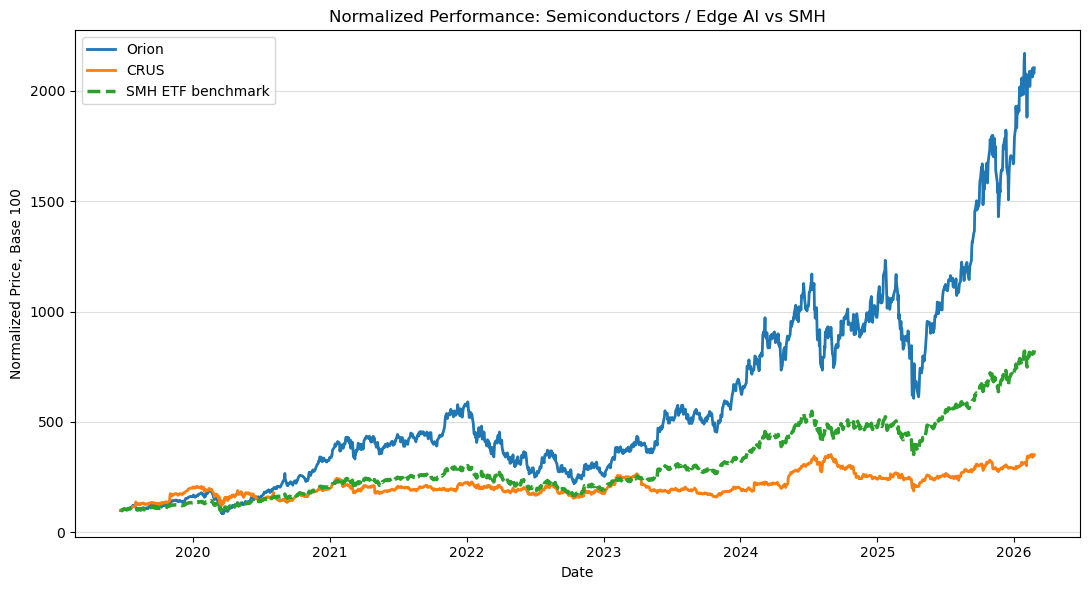

Saved chart to: /home/lucap/IE_University_Linux/Other/eden_application/notebooks/data_notebook1/output_data/charts/02_semiconductor_theme_vs_smh.png


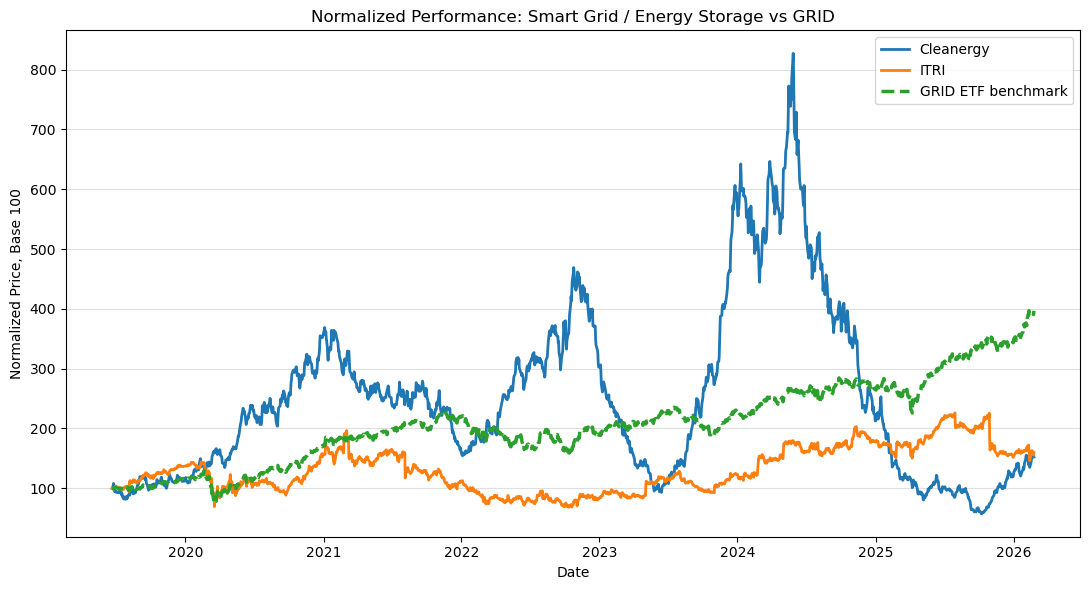

Saved chart to: /home/lucap/IE_University_Linux/Other/eden_application/notebooks/data_notebook1/output_data/charts/02_smart_grid_theme_vs_grid.png


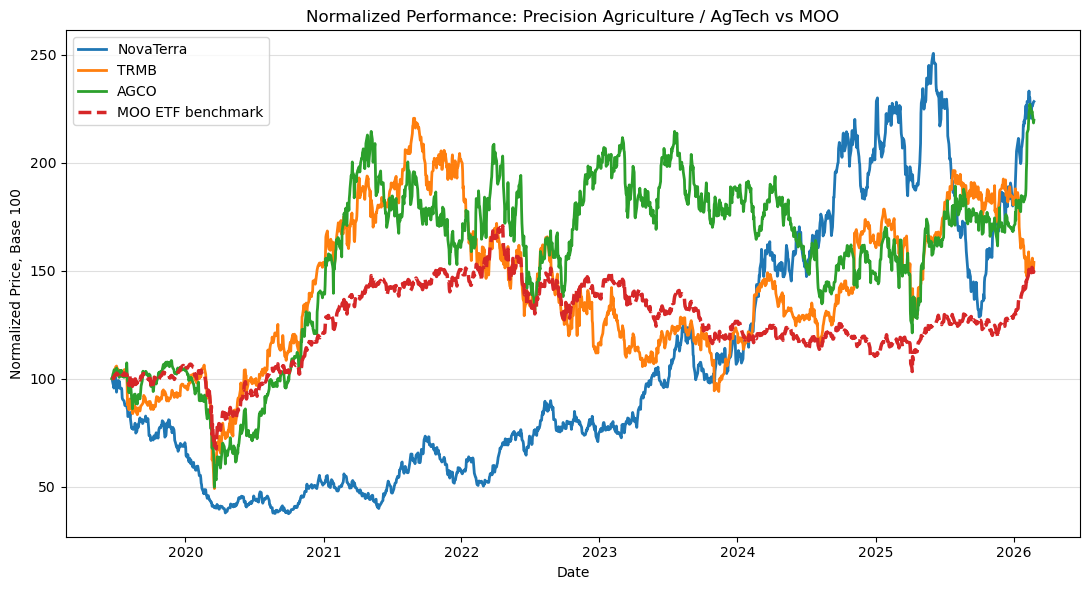

Saved chart to: /home/lucap/IE_University_Linux/Other/eden_application/notebooks/data_notebook1/output_data/charts/02_agtech_theme_vs_moo.png

Theme benchmark charts exported:
/home/lucap/IE_University_Linux/Other/eden_application/notebooks/data_notebook1/output_data/charts/02_semiconductor_theme_vs_smh.png
/home/lucap/IE_University_Linux/Other/eden_application/notebooks/data_notebook1/output_data/charts/02_smart_grid_theme_vs_grid.png
/home/lucap/IE_University_Linux/Other/eden_application/notebooks/data_notebook1/output_data/charts/02_agtech_theme_vs_moo.png


In [25]:
# ============================================================
# Normalized Performance Charts: Candidates and Public Stocks vs ETF Benchmarks
# ============================================================
#
# Objective:
# Plot each fictional candidate and eligible public stock alternative
# against the closest thematic ETF benchmark on a normalized base-100 basis.
#
# Each chart groups all comparable securities within the same theme:
# - Orion and CRUS vs SMH
# - Cleanergy and ITRI vs GRID
# - NovaTerra, TRMB, and AGCO vs MOO
# ============================================================

# Build one price dataframe containing both fictional candidates and public securities.
candidate_price_columns = []

for candidate, df in price_data.items():
    if "Close" not in df.columns:
        raise ValueError(f"{candidate} price dataframe does not contain a 'Close' column.")

    candidate_price_columns.append(
        df["Close"].rename(candidate)
    )

candidate_prices_for_charts = pd.concat(
    candidate_price_columns,
    axis=1
)

all_prices_for_charts = pd.concat(
    [
        candidate_prices_for_charts,
        public_prices_clean,
    ],
    axis=1
)

all_prices_for_charts = all_prices_for_charts.loc[
    :,
    ~all_prices_for_charts.columns.duplicated()
]

# Use the combined metrics table to identify which securities are actually included
# in the comparison universe after the public-stock eligibility filters.
securities_in_comparison = comparison_metrics_df["Ticker"].tolist()

benchmark_chart_specs = {
    "SMH": {
        "Theme": "Semiconductors / Edge AI",
        "Preferred Order": ["Orion", "CRUS", "SMH"],
        "Output Name": "02_semiconductor_theme_vs_smh.png",
    },
    "GRID": {
        "Theme": "Smart Grid / Energy Storage",
        "Preferred Order": ["Cleanergy", "ITRI", "GRID"],
        "Output Name": "02_smart_grid_theme_vs_grid.png",
    },
    "MOO": {
        "Theme": "Precision Agriculture / AgTech",
        "Preferred Order": ["NovaTerra", "TRMB", "AGCO", "MOO"],
        "Output Name": "02_agtech_theme_vs_moo.png",
    },
}

exported_theme_chart_paths = []

for benchmark, chart_spec in benchmark_chart_specs.items():

    theme = chart_spec["Theme"]
    preferred_order = chart_spec["Preferred Order"]

    tickers_to_plot = [
        ticker
        for ticker in preferred_order
        if ticker in securities_in_comparison
        and ticker in all_prices_for_charts.columns
    ]

    # The benchmark must be present for the chart to be meaningful.
    if benchmark not in tickers_to_plot:
        print(f"Skipping {theme}: benchmark {benchmark} is not available.")
        continue

    # Require at least one comparable security in addition to the benchmark.
    if len(tickers_to_plot) < 2:
        print(f"Skipping {theme}: no comparable security available against {benchmark}.")
        continue

    aligned_prices = all_prices_for_charts[tickers_to_plot].dropna()

    if len(aligned_prices) < 2:
        print(f"Skipping {theme}: insufficient aligned observations.")
        continue

    normalized_prices = aligned_prices / aligned_prices.iloc[0] * 100

    plt.figure(figsize=(11, 6))

    for ticker in tickers_to_plot:
        if ticker == benchmark:
            plt.plot(
                normalized_prices.index,
                normalized_prices[ticker],
                label=f"{ticker} ETF benchmark",
                linestyle="--",
                linewidth=2.5,
            )
        else:
            plt.plot(
                normalized_prices.index,
                normalized_prices[ticker],
                label=ticker,
                linewidth=2,
            )

    plt.title(f"Normalized Performance: {theme} vs {benchmark}")
    plt.ylabel("Normalized Price, Base 100")
    plt.xlabel("Date")
    plt.legend()
    plt.grid(axis="y", alpha=0.4)
    plt.tight_layout()

    chart_path = OUTPUT_CHARTS / chart_spec["Output Name"]

    plt.savefig(
        chart_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    exported_theme_chart_paths.append(chart_path)
    print("Saved chart to:", chart_path)

print("\nTheme benchmark charts exported:")
for chart_path in exported_theme_chart_paths:
    print(chart_path)



### Normalized Performance Charts — Interpretation

The normalized performance charts compare each fictional candidate with both its closest ETF benchmark and the eligible public stock alternatives in the same theme. All series are rebased to 100, so the charts compare relative performance paths rather than absolute prices.

**Semiconductors / Edge AI — Orion vs CRUS vs SMH:**  
Orion materially outperforms both CRUS and SMH over the full sample, especially from 2023 onward. This supports Orion’s standalone quantitative upside case. However, the chart also shows that Orion is a much more aggressive single-name exposure than either CRUS or the diversified semiconductor ETF benchmark. CRUS appears materially less compelling from a return perspective, while SMH provides a smoother and more diversified way to express the semiconductor theme. The key investment question is therefore not whether Orion has stronger upside, but whether EDEN should accept additional semiconductor/AI concentration given the existing ASML position.

**Smart Grid / Energy Storage — Cleanergy vs ITRI vs GRID:**  
Cleanergy shows the most explosive upside phase, especially around 2024, but the gains reverse sharply afterward. By the end of the sample, GRID has delivered the strongest and smoothest long-term profile among the three, while ITRI is more stable than Cleanergy but also less attractive than GRID on the chart. This weakens Cleanergy’s standalone quantitative case: if the objective were only to express smart-grid infrastructure exposure, GRID appears to be the cleaner public benchmark. Cleanergy therefore needs to be justified through portfolio fit, learning value, and differentiated single-name upside rather than through superior standalone performance.

**Precision Agriculture / AgTech — NovaTerra vs TRMB / AGCO vs MOO:**  
NovaTerra has the weakest early-period performance but recovers strongly from 2024 onward and ends near the top of the group. TRMB and AGCO perform better during the earlier part of the sample, while MOO is the smoother diversified agribusiness benchmark. The chart suggests that NovaTerra has become more compelling recently, but its performance path is volatile and highly path-dependent. TRMB and AGCO remain credible public alternatives because they provide real, investable agriculture/technology exposure with less reliance on the fictional AI-agriculture thesis. NovaTerra should therefore not be recommended purely on the basis of diversification; it would need a stronger business-quality and recent-momentum argument.

**Overall implication:**  
The charts strengthen Orion’s upside case, weaken Cleanergy’s standalone quantitative case, and make NovaTerra more nuanced than a simple rejection. However, chart performance alone is not the final decision criterion. The final recommendation should combine these results with risk-adjusted metrics, max drawdown, portfolio fit, EDEN compliance, and the public-alternative rejection test.

In [26]:
# ============================================================
# Investment Universe Screening Table
# ============================================================
#
# Objective:
# Document how each public ETF/stock alternative is used in the
# analysis. This table is exported for Notebook 04 / appendix use
# rather than displayed in full in Notebook 02.
# ============================================================

screening_rows = []

for ticker, description in etf_benchmarks.items():
    screening_rows.append({
        "Ticker": ticker,
        "Type": "ETF",
        "Theme": description,
        "EDEN Compliance View": "Likely compliant as public ETF; still check liquidity and instrument structure",
        "Market-Cap Screen Required?": False,
        "Market-Cap Eligible?": "N/A - ETF benchmark",
        "Market Cap $bn": np.nan,
        "Role in Analysis": "Full quant benchmark and possible diversified alternative",
        "Included in Main Quant Comparison?": ticker in public_prices_clean.columns,
        "Reason / Caveat": "ETF alternative to fictional single-name exposure",
    })

for ticker, description in stock_alternatives.items():

    market_cap_row = market_cap_screen_df.loc[
        market_cap_screen_df["Ticker"] == ticker
    ]

    if market_cap_row.empty:
        market_cap_eligible = False
        market_cap_bn = np.nan
    else:
        market_cap_eligible = bool(market_cap_row["Market-Cap Eligible"].iloc[0])
        market_cap_bn = market_cap_row["Market Cap $bn"].iloc[0]

    included = ticker in public_prices_clean.columns

    screening_rows.append({
        "Ticker": ticker,
        "Type": "Stock",
        "Theme": description,
        "EDEN Compliance View": "Requires profitability, OECD-listing, and normal-equity check",
        "Market-Cap Screen Required?": True,
        "Market-Cap Eligible?": market_cap_eligible,
        "Market Cap $bn": market_cap_bn,
        "Role in Analysis": (
            "Full quant comparison and possible public stock alternative"
            if included
            else "Excluded from final public-stock alternative set"
        ),
        "Included in Main Quant Comparison?": included,
        "Reason / Caveat": (
            "Passes market-cap screen; still requires profitability and listing-market confirmation"
            if included
            else "Excluded because it failed the market-cap screen or lacked usable price data"
        ),
    })

for ticker, description in qualitative_only_comps.items():
    screening_rows.append({
        "Ticker": ticker,
        "Type": "Qualitative Comparable",
        "Theme": description,
        "EDEN Compliance View": "Not treated as eligible final alternative",
        "Market-Cap Screen Required?": "Not screened",
        "Market-Cap Eligible?": "Not used as eligible alternative",
        "Market Cap $bn": np.nan,
        "Role in Analysis": "Qualitative comparable only",
        "Included in Main Quant Comparison?": False,
        "Reason / Caveat": "Useful for peer context, but not treated as a main investable alternative",
    })

investment_universe_screening_df = pd.DataFrame(screening_rows)

print(
    "Investment universe screening table created for export. "
    f"Rows: {len(investment_universe_screening_df)}"
)

display(investment_universe_screening_df)


Investment universe screening table created for export. Rows: 25


,Ticker,Type,Theme,EDEN Compliance View,Market-Cap Screen Required?,Market-Cap Eligible?,Market Cap $bn,Role in Analysis,Included in Main Quant Comparison?,Reason / Caveat
0,SMH,ETF,Orion benchmark: semiconductors / AI chips,Likely compliant as public ETF; still check li...,False,N/A - ETF benchmark,NaN,Full quant benchmark and possible diversified ...,True,ETF alternative to fictional single-name exposure
1,GRID,ETF,Cleanergy benchmark: smart-grid infrastructure,Likely compliant as public ETF; still check li...,False,N/A - ETF benchmark,NaN,Full quant benchmark and possible diversified ...,True,ETF alternative to fictional single-name exposure
2,MOO,ETF,NovaTerra benchmark: agribusiness,Likely compliant as public ETF; still check li...,False,N/A - ETF benchmark,NaN,Full quant benchmark and possible diversified ...,True,ETF alternative to fictional single-name exposure
3,CRUS,Stock,Orion alternative: profitable mid-cap fabless ...,"Requires profitability, OECD-listing, and norm...",True,True,8.294427,Full quant comparison and possible public stoc...,True,Passes market-cap screen; still requires profi...
4,ITRI,Stock,Cleanergy alternative: smart-grid / utility in...,"Requires profitability, OECD-listing, and norm...",True,True,3.550252,Full quant comparison and possible public stoc...,True,Passes market-cap screen; still requires profi...
5,TRMB,Stock,"NovaTerra alternative: positioning, software, ...","Requires profitability, OECD-listing, and norm...",True,True,12.632313,Full quant comparison and possible public stoc...,True,Passes market-cap screen; still requires profi...
6,AGCO,Stock,NovaTerra alternative: agricultural equipment ...,"Requires profitability, OECD-listing, and norm...",True,True,8.429077,Full quant comparison and possible public stoc...,True,Passes market-cap screen; still requires profi...
7,LSCC,Qualitative Comparable,"Relevant low-power semiconductor peer, but exc...",Not treated as eligible final alternative,Not screened,Not used as eligible alternative,NaN,Qualitative comparable only,False,"Useful for peer context, but not treated as a ..."
8,ALGM,Qualitative Comparable,Relevant automotive/industrial semiconductor p...,Not treated as eligible final alternative,Not screened,Not used as eligible alternative,NaN,Qualitative comparable only,False,"Useful for peer context, but not treated as a ..."
9,SOXX,Qualitative Comparable,Secondary Orion ETF benchmark; excluded to avo...,Not treated as eligible final alternative,Not screened,Not used as eligible alternative,NaN,Qualitative comparable only,False,"Useful for peer context, but not treated as a ..."


In [27]:
# Export investment universe screening table for Notebook 04 / appendix use

screening_path = OUTPUT_TABLES / "02_investment_universe_screening.csv"

investment_universe_screening_df.to_csv(screening_path, index=False)

print("Exported investment universe screening table to:")
print(screening_path)

Exported investment universe screening table to:
/home/lucap/IE_University_Linux/Other/eden_application/notebooks/data_notebook1/output_data/tables/02_investment_universe_screening.csv


In [28]:
# ============================================================
# Final Export Summary
# ============================================================

print("\nKey tables exported to:")
print(OUTPUT_TABLES / "candidate_metrics_raw.csv")
print(OUTPUT_TABLES / "candidate_return_correlations.csv")
print(OUTPUT_TABLES / "02_public_stock_market_cap_screen.csv")
print(OUTPUT_TABLES / "02_public_alternative_metrics_raw.csv")
print(OUTPUT_TABLES / "02_candidate_vs_public_alternatives_metrics_raw.csv")
print(OUTPUT_TABLES / "02_candidate_public_benchmark_beta_correlation.csv")
print(OUTPUT_TABLES / "02_investment_universe_screening.csv")

print("\nKey charts exported to:")
print(OUTPUT_CHARTS / "candidate_growth_of_1.png")
print(OUTPUT_CHARTS / "candidate_drawdowns.png")
print(OUTPUT_CHARTS / "candidate_var_cvar_eur.png")
print(OUTPUT_CHARTS / "02_semiconductor_theme_vs_smh.png")
print(OUTPUT_CHARTS / "02_smart_grid_theme_vs_grid.png")
print(OUTPUT_CHARTS / "02_agtech_theme_vs_moo.png")


Key tables exported to:
/home/lucap/IE_University_Linux/Other/eden_application/notebooks/data_notebook1/output_data/tables/candidate_metrics_raw.csv
/home/lucap/IE_University_Linux/Other/eden_application/notebooks/data_notebook1/output_data/tables/candidate_return_correlations.csv
/home/lucap/IE_University_Linux/Other/eden_application/notebooks/data_notebook1/output_data/tables/02_public_stock_market_cap_screen.csv
/home/lucap/IE_University_Linux/Other/eden_application/notebooks/data_notebook1/output_data/tables/02_public_alternative_metrics_raw.csv
/home/lucap/IE_University_Linux/Other/eden_application/notebooks/data_notebook1/output_data/tables/02_candidate_vs_public_alternatives_metrics_raw.csv
/home/lucap/IE_University_Linux/Other/eden_application/notebooks/data_notebook1/output_data/tables/02_candidate_public_benchmark_beta_correlation.csv
/home/lucap/IE_University_Linux/Other/eden_application/notebooks/data_notebook1/output_data/tables/02_investment_universe_screening.csv

Key c